In [1]:
import jax 
import jax.numpy as jnp
import haiku as hk
import optax

from probjax.nn.transformers import Transformer
from probjax.nn.tokenizer import scalarize, ScalarTokenizer
from probjax.nn.helpers import GaussianFourierEmbedding, SinusoidalEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss

import matplotlib.pyplot as plt

from functools import partial

In [2]:
jax.devices()

I0000 00:00:1701078936.195639  239928 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.


[gpu(id=0),
 gpu(id=1),
 gpu(id=2),
 gpu(id=3),
 gpu(id=4),
 gpu(id=5),
 gpu(id=6),
 gpu(id=7)]

In [3]:
from sbibm import get_task

task = get_task("two_moons")
prior = task.get_prior_dist()
simulator = task.get_simulator()

thetas = prior.sample((100000,))
xs = simulator(thetas)

thetas = jnp.array(thetas)
xs = jnp.array(xs)


2023-11-27 10:55:53.160810: W external/xla/xla/service/gpu/nvptx_compiler.cc:708] The NVIDIA driver's CUDA version is 11.7 which is older than the ptxas CUDA version (11.8.89). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [4]:
data = jnp.hstack([thetas, xs])
theta_dim = thetas.shape[-1]
x_dim = xs.shape[-1]

In [5]:
from probjax.distributions.sde import VPSDE, BaseSDE
from probjax.distributions import Normal, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions.discrete import Empirical

In [6]:
p0 = Independent(Empirical(data), 1)
beta_max = 10.
beta_min = 0.01
sde = VPSDE(p0, beta_max=beta_max, beta_min=beta_min)
t = jnp.linspace(0,1,200)

In [7]:
mean_data = p0.mean

def output_scale_fn(t, x):
    scale = jnp.sqrt(jnp.sum(sde.marginal_variance(t[..., None], x0=jnp.ones_like(x)), -1))
    return jnp.clip(1/scale[..., None],a_min=0.01, a_max=100.) * x

In [8]:
def naive_mlp(output_dim:int, hidden_dim:int = 100, num_hidden:int=6, activation=jax.nn.gelu, layer_norm:bool = True):
    
    def score_net(t, x, context):
        
        x, context = jnp.broadcast_arrays(x, context)
        x = jnp.concatenate([x, context], axis=-1)
        
        time_embedding = GaussianFourierEmbedding(hidden_dim)(t[...,None])
        h = activation(hk.Linear(hidden_dim)(x) + time_embedding)
        
        
        for _ in range(num_hidden - 1):
            h_new = hk.Linear(hidden_dim)(h)
            h_new += time_embedding
            h = activation(h_new)
            
            if layer_norm:
                h = hk.LayerNorm(axis=-1, create_scale=True, create_offset=True)(h)
            
        out = hk.Linear(output_dim)(h)
        out = output_scale_fn(t, out)
        return out
    
    init_fn, apply_fn = hk.without_apply_rng(hk.transform(score_net))
    return init_fn, apply_fn


init_fn, model_fn = naive_mlp(output_dim=theta_dim)
params = init_fn(jax.random.PRNGKey(42), jnp.ones((10,)), thetas[:10], xs[:10])
out = model_fn(params, jnp.ones((10,)), thetas[:10], xs[:10])

In [9]:
# VPSDE 
T = 1.
T_min = 1e-5

def weight_fn(t):
    t = t.reshape(-1, 1)
    return 1-jnp.exp(-0.5 * (beta_max - beta_min) * t**2 - beta_min * t) + 1e-4

# def weight_fn(t):
#     return 1.

In [10]:
def loss_fn(params, key, data):
    thetas, xs = jnp.split(data, 2, axis=-1)
    key_times, key_loss, key_condition = jax.random.split(key,3)
    times = jax.random.uniform(key_times, (data.shape[0],), minval=T_min, maxval =1.)
    loss = denoising_score_matching_loss(params, key_loss, times, thetas, None, xs, model_fn = model_fn, mean_fn = sde.marginal_mean, std_fn=sde.marginal_stddev, weight_fn=weight_fn, axis=-1)
    return loss



@partial(jax.pmap, axis_name="num_devices")
def update(params, opt_state, key, data):
    loss, grads = jax.value_and_grad(loss_fn)(params, key, data)

    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state
    

In [11]:
num_epochs = 1000
batch_size = 4000
num_devices = jax.device_count()
batch_size_per_device = batch_size // num_devices
num_steps = data.shape[0] // batch_size + 1

In [12]:
total_number_steps = num_epochs * num_steps
schedule = optax.linear_schedule(5e-4, 0., total_number_steps//2, total_number_steps//2)
optimizer = optax.chain(optax.adaptive_grad_clip(5.), optax.adam(schedule))
opt_state = optimizer.init(params)

In [13]:
print(total_number_steps)

26000


In [14]:
replicated_params = jax.tree_map(lambda x: jnp.array([x] * num_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * num_devices), opt_state)

In [15]:

key = jax.random.PRNGKey(1)
for j in range(num_epochs):
    l = 0
    for i in range(num_steps):
        key, key_batch, key_update = jax.random.split(key, 3)
        data_batch = jax.random.choice(key_batch,data, shape=(num_devices, batch_size_per_device, ), axis=0, replace=False)
        #node_id_batch = jnp.repeat(node_id[None,...], num_devices, axis=0)
        loss, replicated_params, replicated_opt_state = update(replicated_params, replicated_opt_state, jax.random.split(key_update, (num_devices,)), data_batch)
        l += loss[0] /num_steps
    if (j % 100) == 0:     
        print(l)

1.1422757
0.30043086
0.29642588
0.22744718
0.25819018
0.2934056
0.2938506
0.24459839
0.24213752
0.3074906


In [16]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [17]:

def sde_fn(condition_mask):

    def score_fn(t, x):
        theta, x = jnp.split(x, 2, axis=-1)
        score = model_fn(params, jnp.atleast_1d(t), theta, x)
        score_pad = jnp.zeros_like(score)
        score = jnp.concatenate([score, score_pad], axis=-1)
        return score[0]

    def drift_backwards(t, x):
        t = (1- t)
        score = score_fn(t, x)
        drift = sde.drift(t, x) - sde.diffusion(t, x)**2 * score 
        drift = -drift * (1-condition_mask.reshape(x.shape))
        #print(drift.shape)
        return drift

    def diffusion_backwards(t, x):
        t = (1-t)
        diffusion = sde.diffusion(t, x) 
        return diffusion * (1-condition_mask.reshape(x.shape))

    return drift_backwards, diffusion_backwards

In [18]:
condition_value = data[0].reshape(1, -1 ,1)
condition_mask = jnp.array([0]*theta_dim + [1]*x_dim).reshape(1,-1,1)

In [19]:
from probjax.utils.sdeint import sdeint

In [20]:
def sample_fn(key, shape, x_o, condition_mask):
    key1, key2 = jax.random.split(key, 2)
    drift, diffusion = sde_fn(condition_mask)
    x_T = jax.random.normal(key1, shape + (4,)) #* marginal_std(jnp.zeros((1,)), 1.) + marginal_mean(jnp.zeros((1,)), 1.)
    condition_mask = condition_mask.reshape(1, -1, 1)
    x_T = x_T[..., None] * (1-condition_mask) + x_o * condition_mask
    x_T = x_T.reshape(shape + (theta_dim+x_dim,))
    keys = jax.random.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, drift, diffusion, x_T, jnp.linspace(0., 1-T_min, 500))
    return ys

In [21]:
from sbi.analysis.sbc import c2st
import torch
import numpy as np

In [22]:

c2sts = []
for i in range(1,11):
    x_o = task.get_observation(i)
    samples_post = task.get_reference_posterior_samples(i)
    
    x_o = jnp.array(x_o)
    condition_value = condition_value.at[:,theta_dim:,0].set(x_o)
    samples_est = sample_fn(jax.random.PRNGKey(i), (10000,), condition_value, condition_mask)
    samples_est = samples_est[:, -1,:theta_dim]
    print(samples_est.shape)
    metric = c2st(torch.tensor(np.array(samples_est)), samples_post)
    print(metric)

(10000, 2)
tensor([0.5237])
(10000, 2)


KeyboardInterrupt: 

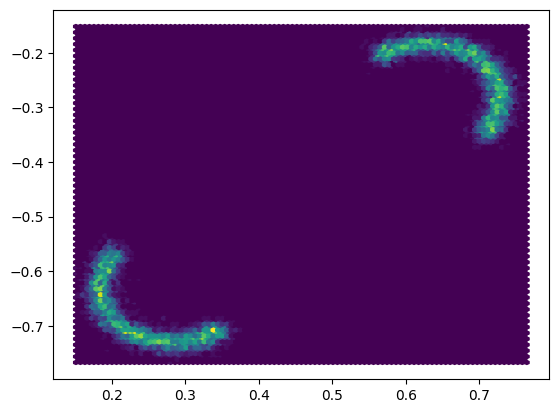

In [50]:
plt.hexbin(samples_est[:,0], samples_est[:,1])

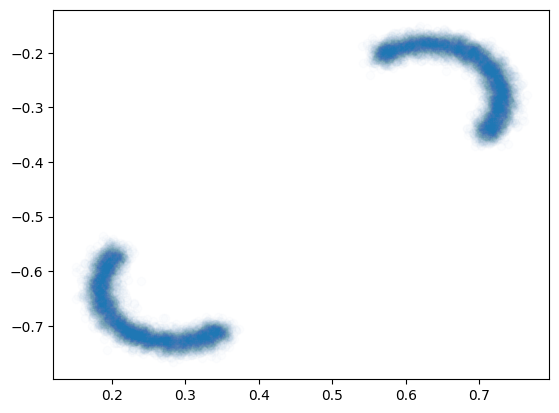

In [51]:
plt.scatter(samples_est[:,0], samples_est[:,1], alpha=0.01)

In [266]:
import sbi
from sbi.inference import SNPE, SNLE, SNRE

posterior = sbi.utils.posterior_nn(model='maf', 
                                    hidden_features=50, 
                                    hidden_layers=2,
                                    num_transforms=5)

inference = SNRE(prior)
density_estimator = inference.append_simulations(torch.as_tensor(np.array(thetas)), torch.as_tensor(np.array(xs))).train(training_batch_size=1000)
posterior = inference.build_posterior()

 Training neural network. Epochs trained: 71

KeyboardInterrupt: 

In [284]:
?inference.train

Signature:
inference.train(
    num_atoms: int = 10,
    training_batch_size: int = 50,
    learning_rate: float = 0.0005,
    validation_fraction: float = 0.1,
    stop_after_epochs: int = 20,
    max_num_epochs: int = 2147483647,
    clip_max_norm: Optional[float] = 5.0,
    resume_training: bool = False,
    discard_prior_samples: bool = False,
    retrain_from_scratch: bool = False,
    show_train_summary: bool = False,
    dataloader_kwargs: Optional[Dict] = None,
) -> torch.nn.modules.module.Module
Docstring:
Return classifier that approximates the ratio $p(\theta,x)/p(\theta)p(x)$.

Args:
    num_atoms: Number of atoms to use for classification.
    training_batch_size: Training batch size.
    learning_rate: Learning rate for Adam optimizer.
    validation_fraction: The fraction of data to use for validation.
    stop_after_epochs: The number of epochs to wait for improvement on the
        validation set before terminating training.
    max_num_epochs: Maximum number of epochs

In [263]:
?sbi.utils.posterior_nn

Signature:
sbi.utils.posterior_nn(
    model: str,
    z_score_theta: Optional[str] = 'independent',
    z_score_x: Optional[str] = 'independent',
    hidden_features: int = 50,
    num_transforms: int = 5,
    num_bins: int = 10,
    embedding_net: torch.nn.modules.module.Module = Identity(),
    num_components: int = 10,
    **kwargs,
) -> Callable
Docstring:
Returns a function that builds a density estimator for learning the posterior.

This function will usually be used for SNPE. The returned function is to be passed
to the inference class when using the flexible interface.

Args:
    model: The type of density estimator that will be created. One of [`mdn`,
        `made`, `maf`, `nsf`].
    z_score_theta: Whether to z-score parameters $\theta$ before passing them into
        the network, can take one of the following:
        - `none`, or None: do not z-score.
        - `independent`: z-score each dimension independently.
        - `structured`: treat dimensions as related, there

In [208]:

c2sts = []
for i in range(1,11):
    x_o = task.get_observation(i)
    samples_post = task.get_reference_posterior_samples(i)
    
    posterior = posterior.set_default_x(x_o)
    samples_est = posterior.sample((10000,))
    metric = c2st(torch.tensor(np.array(samples_est)), samples_post)
    print(metric)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

tensor([0.7176])


Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

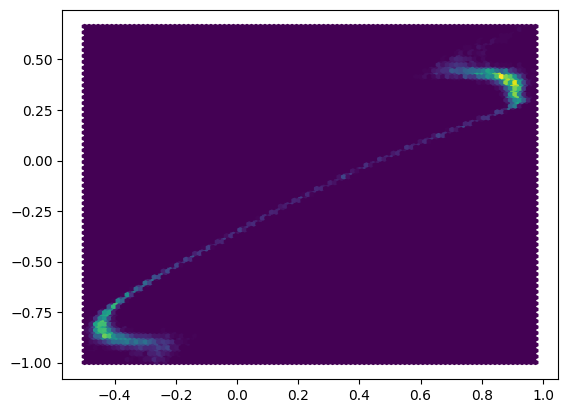

In [209]:
plt.hexbin(samples_est[:,0], samples_est[:,1])